# LLMTIME Tokenization Prediction Pipeline

This notebook implements the PDF section 3.1.2 LLMTIME idea: convert continuous price values into standardized digit strings so a language-model backend can treat forecasting as next-token continuation.

Concept mapping:

- Fixed precision truncation: close values are scaled and converted to fixed-width integer strings.
- Percentile rescaling: train-period close prices are centered by median and scaled by an alpha-percentile absolute deviation, not max value.
- Digit separation: `style="gpt"` injects spaces between digits; `style="llama"` keeps compact digit strings.
- Backend: `hf` uses Hugging Face `transformers` locally through `AutoTokenizer` and `AutoModelForCausalLM`; `local` remains a deterministic fallback; `api` calls an OpenAI-compatible endpoint from environment variables.


In [9]:
from pathlib import Path
import importlib
import json
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import llmtime_backend
import plot_results

importlib.reload(llmtime_backend)
importlib.reload(plot_results)

from benchmark_utils import INDEX_TICKERS
from llmtime_backend import HuggingFaceConfig, LLMTIMEConfig, build_llmtime_prompt, download_index, fit_llmtime_scaler
from plot_results import plot_price_predictions

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Configuration

In [10]:
START = "2010-01-01"
END = "2026-06-01"
TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-05-31"

LOOKBACK = 30
HORIZON = 1
PRECISION = 2
ALPHA = 0.95
TOKEN_STYLE = "gpt"  # "gpt" inserts spaces between digits; "llama" keeps compact numbers.
BACKEND = "hf"       # "hf" uses Hugging Face locally; "local" is a deterministic fallback; "api" uses LLMTIME_API_URL.
HF_MODEL = "distilgpt2"
HF_DEVICE = "auto"
HF_MAX_NEW_TOKENS = 32

OUTPUT_DIR = Path(f"outputs_llmtime_{BACKEND}_h{HORIZON}")
PLOTS_DIR = Path(f"plots_llmtime_{BACKEND}_h{HORIZON}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_PREDICTION = True
config = LLMTIMEConfig(precision=PRECISION, alpha=ALPHA, style=TOKEN_STYLE)
hf_config = HuggingFaceConfig(model=HF_MODEL, device=HF_DEVICE, max_new_tokens=HF_MAX_NEW_TOKENS)


## Inspect One LLMTIME Prompt

In [11]:
example_index = "Nasdaq"
raw = download_index(INDEX_TICKERS[example_index], start=START, end=END)
train_values = raw.loc[:TRAIN_END, "Close"].to_numpy(dtype=float)
scaler = fit_llmtime_scaler(train_values, precision=PRECISION, alpha=ALPHA)
history = raw["Close"].dropna().iloc[-LOOKBACK:].to_numpy(dtype=float)
prompt = build_llmtime_prompt(history, scaler=scaler, horizon=HORIZON, config=config)

print("Scaler offset:", scaler.offset)
print("Scaler scale:", scaler.scale)
print(prompt[:1200])


Scaler offset: 6864.919921875
Scaler scale: 12416.38876953125
Continue the numeric time series. Return only the next encoded value, using the same digit format and separator. Forecast horizon: 1 trading days.
Series: 1 4 1,1 4 1,1 4 0,1 4 3,1 4 1,1 4 4,1 4 5,1 4 3,1 4 3,1 4 5,1 4 6,1 4 6,1 4 8,1 5 2,1 5 2,1 5 6,1 5 6,1 5 4,1 5 7,1 5 9,1 5 5,1 5 4,1 5 3,1 5 6,1 5 6,1 5 6,1 5 9,1 5 9,1 6 1,1 6 1,


## Run LLMTIME Backend And Build Benchmark Outputs

In [12]:
if RUN_PREDICTION:
    cmd = [
        sys.executable,
        str(SRC_DIR / "llmtime_backend.py"),
        "--start", START,
        "--end", END,
        "--train-end", TRAIN_END,
        "--test-start", TEST_START,
        "--test-end", TEST_END,
        "--lookback", str(LOOKBACK),
        "--horizon", str(HORIZON),
        "--output-dir", str(OUTPUT_DIR),
        "--backend", BACKEND,
        "--style", TOKEN_STYLE,
        "--precision", str(PRECISION),
        "--alpha", str(ALPHA),
    ]
    if BACKEND == "hf":
        cmd.extend([
            "--hf-model", HF_MODEL,
            "--hf-device", HF_DEVICE,
            "--hf-max-new-tokens", str(HF_MAX_NEW_TOKENS),
        ])

    print("Running LLMTIME in a clean Python subprocess:")
    print(" ".join(cmd))
    completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
    print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)

summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
summary


Running LLMTIME in a clean Python subprocess:
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\python.exe c:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\src\llmtime_backend.py --start 2010-01-01 --end 2026-06-01 --train-end 2025-12-31 --test-start 2026-01-01 --test-end 2026-05-31 --lookback 30 --horizon 1 --output-dir outputs_llmtime_hf_h1 --backend hf --style gpt --precision 2 --alpha 0.95 --hf-model distilgpt2 --hf-device auto --hf-max-new-tokens 32


Exception in thread Thread-11 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\zoufuc\AppData\Roaming\Python\Python311\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
UnicodeDecodeError: 'cp950' codec can't decode byte 0xe2 in position 1119: illegal multibyte sequence


Running LLMTIME-hf Nasdaq (^IXIC)...
Nasdaq: RMSE=17287.45, MAE=2969.42, MAPE=13.49%, Direction=43.14%
Running LLMTIME-hf SP500 (^GSPC)...
SP500: RMSE=6276.39, MAE=1254.58, MAPE=18.12%, Direction=49.02%
Running LLMTIME-hf SOX (^SOX)...
SOX: RMSE=2403.17, MAE=1004.44, MAPE=10.17%, Direction=36.27%
Saved outputs to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\outputs_llmtime_hf_h1



,index,ticker,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,samples,train_samples,model,features,tokenizer,precision,alpha,hf_model
0,Nasdaq,^IXIC,17287.450915,2969.418809,13.487291,265.655465,212.978860,-6407.470471,-1294.231711,43.137255,102,4024,LLMTIME-hf,['Close'],gpt,2,0.95,distilgpt2
1,SP500,^GSPC,6276.393245,1254.577123,18.121324,58.252660,44.949233,-10674.432058,-2691.097949,49.019608,102,4024,LLMTIME-hf,['Close'],gpt,2,0.95,distilgpt2
2,SOX,^SOX,2403.170577,1004.436650,10.168390,232.848039,180.839107,-932.076795,-455.431106,36.274510,102,4024,LLMTIME-hf,['Close'],gpt,2,0.95,distilgpt2


## Benchmark Summary

In [13]:
metric_cols = [
    "index", "ticker", "model", "samples", "train_samples", "rmse", "mae", "mape_pct",
    "naive_rmse", "naive_mae", "rmse_vs_naive_pct", "mae_vs_naive_pct",
    "direction_accuracy_pct", "tokenizer", "precision", "alpha",
]
summary[metric_cols]


,index,ticker,model,samples,train_samples,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,tokenizer,precision,alpha
0,Nasdaq,^IXIC,LLMTIME-hf,102,4024,17287.450915,2969.418809,13.487291,265.655465,212.978860,-6407.470471,-1294.231711,43.137255,gpt,2,0.95
1,SP500,^GSPC,LLMTIME-hf,102,4024,6276.393245,1254.577123,18.121324,58.252660,44.949233,-10674.432058,-2691.097949,49.019608,gpt,2,0.95
2,SOX,^SOX,LLMTIME-hf,102,4024,2403.170577,1004.436650,10.168390,232.848039,180.839107,-932.076795,-455.431106,36.274510,gpt,2,0.95


## Inspect First Prompt Saved For Each Index

In [14]:
first_prompt_path = OUTPUT_DIR / "Nasdaq_first_prompt.txt"
print(first_prompt_path.read_text(encoding="utf-8")[:1200])


Continue the numeric time series. Return only the next encoded value, using the same digit format and separator. Forecast horizon: 1 trading days.
Series: 1 2 5,1 2 6,1 2 2,1 2 4,1 2 8,1 3 0,1 3 1,1 3 2,1 3 2,1 3 3,1 3 3,1 3 4,1 3 4,1 3 4,1 3 4,1 3 5,1 3 4,1 3 1,1 3 0,1 3 0,1 2 7,1 3 0,1 3 2,1 3 3,1 3 4,1 3 4,1 3 4,1 3 3,1 3 3,1 3 1,


## Generate Price Prediction Plots

In [15]:
for index_name in summary["index"]:
    plot_price_predictions(
        index_name=index_name,
        prediction_path=OUTPUT_DIR / f"{index_name}_predictions.csv",
        output_path=PLOTS_DIR / f"{index_name}_price_prediction.png",
    )

print(f"Saved plots to {PLOTS_DIR.resolve()}")


Saved plots to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\plots_llmtime_hf_h1


## Display Example Plot

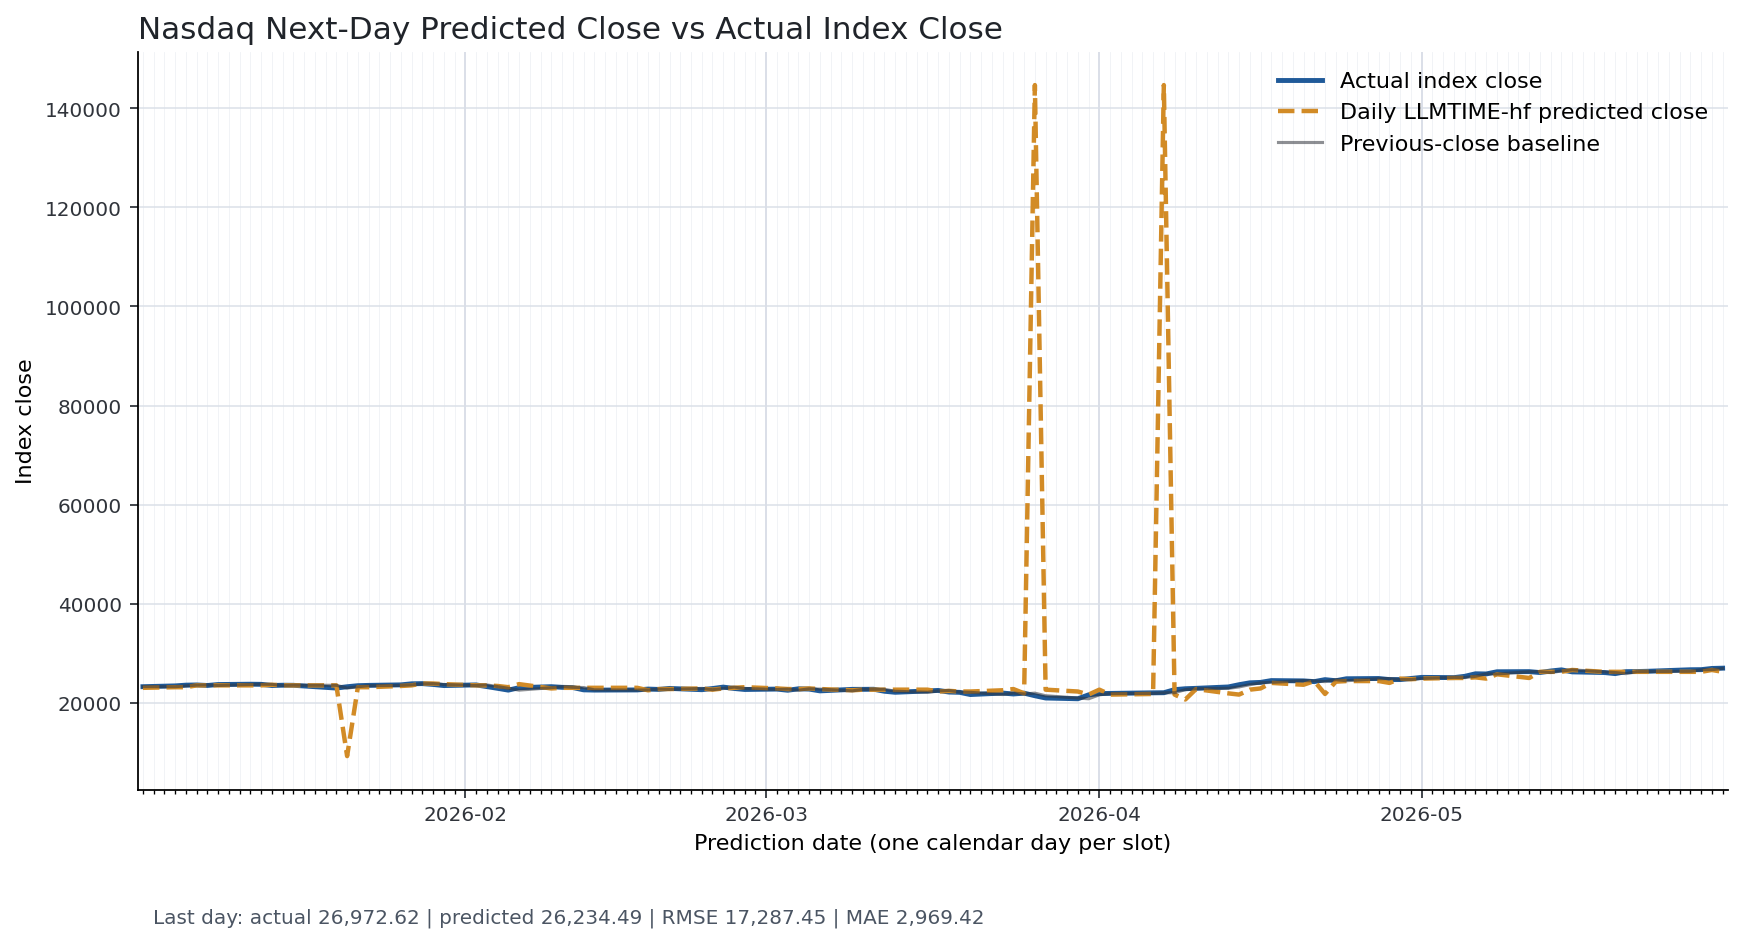

In [16]:
example_plot = PLOTS_DIR / "Nasdaq_price_prediction.png"
if example_plot.exists():
    display(Image(filename=str(example_plot)))
else:
    print(f"Plot not found: {example_plot}")
